# stc tv | Task 3: Recommendations from similar viewers

**Objective.** Recommend programs using the viewing histories of users with similar preferences, show five recommendations for the audience who watched **Moana**, and demonstrate personalized results.

**Source.** `stc TV Data Set_T3.xlsx`, sheet `Sheet1`, provided with the virtual work experience. Run this notebook in Google Colab or Jupyter. Upload the workbook when prompted in Colab. Reading the full workbook may take a few minutes.

**Approach.** Use user-based collaborative filtering with 30 nearest neighbors and cosine similarity. A program watched by a user is an implicit preference signal. The source includes a `rating` column with values 1–4, but does not document how those values were generated, so this simple model uses viewing history rather than interpreting them as explicit likes or dislikes.

## 1. Load the source workbook

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl'])

DATA_FILE = Path('stc TV Data Set_T3.xlsx')
if not DATA_FILE.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(f'Place {DATA_FILE.name} beside this notebook.') from exc
    print(f'Please upload {DATA_FILE.name}.')
    files.upload()

if not DATA_FILE.exists():
    raise FileNotFoundError(f'{DATA_FILE.name} was not uploaded.')

raw = pd.read_excel(DATA_FILE, sheet_name='Sheet1')
print(f'Source rows: {raw.shape[0]:,}; source columns: {raw.shape[1]}')
display(raw.head())

Source rows: 1,048,575; source columns: 6


,Unnamed: 0,user_id_maped,program_name,rating,date_,program_genre
0,0,26138,100 treets,1,2017-05-27,Drama
1,1,7946,Moana,1,2017-05-21,Animation
2,2,7418,The Mermaid Princess,1,2017-08-10,Animation
3,3,19307,The Mermaid Princess,2,2017-07-26,Animation
4,4,15860,Churchill,2,2017-07-07,Biography


## 2. Check the data and prepare unique viewing relationships

Trim text fields and check missing values. Collapse repeated views of the same program by the same user into one relationship: repeated views do not create extra votes in this model. Preserve the titles supplied in the workbook.

In [2]:
print('Missing source values:')
display(raw.isna().sum().rename('missing_rows').to_frame())
print('Source rating distribution:')
display(raw['rating'].value_counts().sort_index().rename('rows').to_frame())

clean = raw[['user_id_maped', 'program_name', 'program_genre']].copy()
del raw
for column in clean.columns:
    clean[column] = clean[column].astype('string').str.strip().replace('', pd.NA)

missing_keys = clean[['user_id_maped', 'program_name']].isna().any(axis=1)
print(f'Rows excluded because a user ID or program title is missing: {missing_keys.sum():,}')
clean = clean.loc[~missing_keys].copy()
clean['program_genre'] = clean['program_genre'].fillna('Unknown')

pairs = clean[['user_id_maped', 'program_name']].drop_duplicates().reset_index(drop=True)
genre_lookup = clean.groupby('program_name')['program_genre'].agg(lambda values: values.mode().iloc[0])
del clean

print(f'Unique user-program relationships: {len(pairs):,}')
print(f'Distinct users: {pairs.user_id_maped.nunique():,}')
print(f'Distinct programs: {pairs.program_name.nunique():,}')
assert not pairs.isna().any().any()
assert not pairs.duplicated().any()
assert 'Moana' in pairs['program_name'].values

Missing source values:


,missing_rows
Unnamed: 0,0
user_id_maped,0
program_name,0
rating,0
date_,0
program_genre,0


Source rating distribution:


,rows
rating,
1,264293
2,260664
3,261505
4,262113


Rows excluded because a user ID or program title is missing: 0


Unique user-program relationships: 440,237
Distinct users: 11,578
Distinct programs: 8,013


## 3. Build a sparse user-program matrix

Rows represent users and columns represent programs. A value of 1 means the user watched that program; 0 means there is no recorded view. Zero is not a negative rating. A sparse matrix stores only the observed relationships and keeps memory use small.

In [3]:
user_codes, users = pd.factorize(pairs['user_id_maped'], sort=True)
program_codes, programs = pd.factorize(pairs['program_name'], sort=True)
matrix = csr_matrix(
    (np.ones(len(pairs), dtype=np.float32), (user_codes, program_codes)),
    shape=(len(users), len(programs)))

print(f'Matrix: {matrix.shape[0]:,} users x {matrix.shape[1]:,} programs')
print(f'Observed relationships: {matrix.nnz:,}')
print(f'Matrix density: {100 * matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.2f}%')
assert matrix.nnz == len(pairs)

NEIGHBORS = 30
neighbor_model = NearestNeighbors(
    n_neighbors=min(NEIGHBORS + 1, len(users)),
    metric='cosine', algorithm='brute', n_jobs=1).fit(matrix)

Matrix: 11,578 users x 8,013 programs
Observed relationships: 440,237
Matrix density: 0.47%


## 4. Score unseen programs using similar users

Cosine similarity compares the overlap in users' viewing histories. Find up to 30 similar users, exclude the target user, and average their viewing signals using similarity as the weight. Exclude programs already watched by the target user. Scores are ranking signals, not probabilities.

In [4]:
def scores_for_user(row, viewing_matrix, neighbor_ids, distances):
    """Weight other users' viewing histories and exclude the user's watched titles."""
    keep = (neighbor_ids != row) & (distances < 1 - 1e-7)
    selected = neighbor_ids[keep][:NEIGHBORS]
    weights = (1 - distances[keep][:NEIGHBORS]).clip(0, 1)
    scores = np.zeros(viewing_matrix.shape[1], dtype=np.float32)
    if len(selected):
        scores = np.asarray(weights @ viewing_matrix[selected]).ravel() / weights.sum()
    scores[viewing_matrix[row].indices] = 0
    return scores


def top_programs(scores, n=5):
    """Rank positive scores; use alphabetical order for tied scores."""
    candidates = np.flatnonzero(scores > 0)
    names = np.asarray(programs)[candidates]
    return candidates[np.lexsort((names, -scores[candidates]))[:n]]


def recommendation_table(scores, n=5):
    indices = top_programs(scores, n)
    titles = np.asarray(programs)[indices]
    return pd.DataFrame({
        'program': titles,
        'genre': genre_lookup.reindex(titles).to_numpy(),
        'recommendation_score': scores[indices]
    })


def recommend_for_user(user_id, n=5):
    """Return recommendations for a known user in the supplied workbook."""
    row = users.get_indexer([str(user_id).strip()])[0]
    if row == -1:
        raise ValueError('Unknown user ID; no viewing history is available.')
    distances, neighbors = neighbor_model.kneighbors(matrix[row])
    scores = scores_for_user(row, matrix, neighbors[0], distances[0])
    return recommendation_table(scores, n)

## 5. Top five recommendations for the Moana audience

Identify every user who watched Moana and compute their personalized scores. Average those scores across the audience to rank five titles for the group. A title already watched by a particular user contributes zero to that user's score. This group ranking summarizes opportunities across the audience; each user's own list can differ. Genres are displayed for interpretation and are not used in scoring.

Viewers who watched Moana: 2,173


,program,genre,average_score
0,The Jetsons & WWE: Robo-WrestleMania!,Animation,0.1203
1,Surf's Up : WaveMania,Animation,0.1121
2,Rings,Horror,0.1085
3,The Mermaid Princess,Animation,0.1057
4,Collateral Beauty,Drama,0.1033


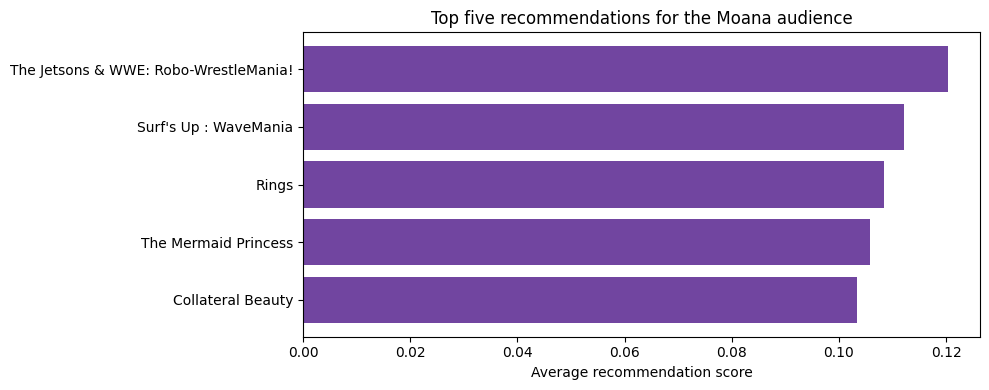

In [5]:
moana_column = programs.get_loc('Moana')
moana_users = matrix[:, moana_column].nonzero()[0]
print(f'Viewers who watched Moana: {len(moana_users):,}')

distances, neighbors = neighbor_model.kneighbors(matrix[moana_users])
score_total = np.zeros(len(programs), dtype=np.float64)
for i, row in enumerate(moana_users):
    score_total += scores_for_user(row, matrix, neighbors[i], distances[i])

audience_scores = score_total / len(moana_users)
moana_top5 = recommendation_table(audience_scores).rename(
    columns={'recommendation_score': 'average_score'})
assert len(moana_top5) == 5 and 'Moana' not in moana_top5['program'].values
display(moana_top5.round({'average_score': 4}))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(moana_top5['program'][::-1], moana_top5['average_score'][::-1], color='#7145A0')
ax.set_title('Top five recommendations for the Moana audience')
ax.set_xlabel('Average recommendation score')
plt.tight_layout()
plt.show()

## 6. Examples of personalized recommendations

Show results for the first three Moana viewers in the sorted user list. Each list uses that viewer's full history, so recommendations can span different genres. The checks below confirm that Moana and other watched titles are excluded.

In [6]:
for row in moana_users[:3]:
    user_id = users[row]
    recommendations = recommend_for_user(user_id)
    watched = set(np.asarray(programs)[matrix[row].indices])
    assert set(recommendations['program']).isdisjoint(watched)
    print(f'User {user_id}: {matrix[row].nnz} distinct programs watched')
    display(recommendations.round({'recommendation_score': 4}))

User 1000: 47 distinct programs watched


,program,genre,recommendation_score
0,Broken Vows,Thriller,0.4415
1,The Birth of a Nation,Biography,0.4373
2,The Boss Baby,Animation,0.3979
3,Rings,Horror,0.2379
4,The Jetsons & WWE: Robo-WrestleMania!,Animation,0.2320


User 10007: 5 distinct programs watched


,program,genre,recommendation_score
0,The Mermaid Princess,Animation,0.4277
1,Trolls,Animation,0.3648
2,Collateral Beauty,Drama,0.2988
3,Surf's Up : WaveMania,Animation,0.1279
4,The Adventures of Petey and Friends,Animation,0.0678


User 10029: 12 distinct programs watched


,program,genre,recommendation_score
0,The Boss Baby,Animation,0.3896
1,Storks,Animation,0.2052
2,Assassin's Creed,Action,0.1302
3,Why Him,Comedy,0.1297
4,Transfiguration,Horror,0.1044


## 7. A small offline check

Use a reproducible sample of 200 users with at least five distinct watched programs. Hide one watched program per sampled user, rebuild the neighbor model using the remaining relationships, and check whether the hidden program appears in the first five recommendations. Compare with a popularity baseline that also excludes watched titles.

**Hit rate at 5** is the fraction of sampled users whose hidden title is recovered. This random holdout is a demonstration on users with enough history; it does not measure future production performance or users with very little history.

In [7]:
rng = np.random.default_rng(42)
eligible = np.flatnonzero(matrix.getnnz(axis=1) >= 5)
validation_users = rng.choice(eligible, size=200, replace=False)
held_out = [rng.choice(matrix[row].indices) for row in validation_users]

training_matrix = matrix.tolil(copy=True)
for row, program in zip(validation_users, held_out):
    training_matrix[row, program] = 0
training_matrix = training_matrix.tocsr()
training_matrix.eliminate_zeros()

validation_model = NearestNeighbors(
    n_neighbors=NEIGHBORS + 1, metric='cosine', algorithm='brute', n_jobs=1).fit(training_matrix)
distances, neighbors = validation_model.kneighbors(training_matrix[validation_users])
popularity = np.asarray(training_matrix.sum(axis=0)).ravel()

model_hits = baseline_hits = 0
for i, (row, expected_program) in enumerate(zip(validation_users, held_out)):
    assert training_matrix[row, expected_program] == 0
    scores = scores_for_user(row, training_matrix, neighbors[i], distances[i])
    model_hits += expected_program in top_programs(scores)
    popular_unseen = popularity.copy()
    popular_unseen[training_matrix[row].indices] = 0
    baseline_hits += expected_program in top_programs(popular_unseen)

evaluation = pd.DataFrame({
    'model': ['Similar users', 'Popularity baseline'],
    'recovered_hidden_titles': [model_hits, baseline_hits],
    'sampled_users': [len(validation_users), len(validation_users)],
    'hit_rate_at_5': [model_hits / len(validation_users), baseline_hits / len(validation_users)]
})
display(evaluation)

,model,recovered_hidden_titles,sampled_users,hit_rate_at_5
0,Similar users,56,200,0.280
1,Popularity baseline,21,200,0.105


## 8. Findings and limitations

- The supplied sheet contains **1,048,575 records**, with no missing source values. Collapsing repeated user-program views produces **440,237 relationships**, covering **11,578 users** and **8,013 programs**.
- **2,173 users** watched Moana. Their aggregated personalized ranking recommends **The Jetsons & WWE: Robo-WrestleMania!**, **Surf's Up : WaveMania**, **Rings**, **The Mermaid Princess**, and **Collateral Beauty**.
- In the 200-user hidden-title check, the similar-user model recovers **56 titles (28.0%)**, compared with **21 titles (10.5%)** for the popularity baseline. This supports the usefulness of matching viewing histories in this sample.
- Personalized lists vary because Moana viewers have different histories. The audience's histories span multiple genres, and a group recommendation is not a guaranteed unseen title for every member of that audience.

**Limits.** Watching a program does not prove that a user liked it. Users without a recorded history need another starting method, such as popular programs. The workbook contains the maximum number of data rows in an Excel sheet, so these results describe the supplied sheet and may not cover all viewing activity. Title availability, release timing, and the undocumented rating scale are not modeled.